# 14. Host Fraction Gaussian Model Figures

This notebook assembles the main figure set for the Gaussian mixed-model host-fraction story:
overview plots, mixed-model summary plots, focused chronicity/location follow-up, and patient/batch random-effect structure.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Markdown, SVG, display

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import workflow_core as wc

context, base_data, base, advanced = wc.bootstrap_notebook()

## Load Host Inputs And Refit The Gaussian Mixed Model


In [2]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid", context="talk")

host_effects = pd.read_csv(wc.table_path(context, 9, "host_mixed_effects"), sep="\t")
host_status = pd.read_csv(wc.table_path(context, 10, "host_mixed_status"), sep="\t")

host_model_effects = host_effects.loc[
    host_effects["model_name"] == advanced.HOST_MODEL_NAME
].copy()
host_model_effects = host_model_effects.loc[
    host_model_effects["term"] != "Intercept"
].copy()


def factor_family(term: str) -> str:
    if "C(body_region" in term:
        return "body_region"
    if "C(chronicity_group" in term:
        return "chronicity_group"
    if "culture_positive" in term:
        return "culture_positive"
    if "years_since_first_sample" in term:
        return "elapsed_time"
    return "other"


host_model_effects["factor_family"] = host_model_effects["term"].map(factor_family)
host_model_effects["term_label"] = host_model_effects["term"].map(
    base.prettify_model_term
)
host_model_effects["posthoc_qvalue"] = np.nan
for family, idx in host_model_effects.groupby("factor_family").groups.items():
    pvals = host_model_effects.loc[list(idx), "pvalue"].to_numpy()
    host_model_effects.loc[list(idx), "posthoc_qvalue"] = multipletests(
        pvals, method="fdr_bh"
    )[1]

qc = base_data["qc"].copy()
host_plot_df = qc.dropna(
    subset=[
        "host_removed_fraction",
        "host_logit",
        "body_region",
        "chronicity_group",
        "patient_id",
        "batch_id",
        "culture_positive_label",
        "years_since_first_sample",
    ]
).copy()
host_plot_df["acute_like_binary"] = np.where(
    host_plot_df["chronicity_group"].astype(str) == "acute_like",
    "Acute-like",
    "Other",
)
host_plot_df["upper_extremity_binary"] = np.where(
    host_plot_df["body_region"].astype(str) == "upper_extremity",
    "Upper extremity",
    "Other",
)

METHODS = ["lbfgs", "powell", "bfgs"]
HOST_MODEL_FORMULA = advanced.HOST_FORMULAS[advanced.HOST_MODEL_NAME]
VC_FORMULA = {"patient": "0 + C(patient_id)", "batch": "0 + C(batch_id)"}


def fit_best_gaussian_mixed_model(frame, formula):
    work = frame.copy()
    work["all_group"] = "all"
    candidates = []
    last_error = None
    for method in METHODS:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                fit = smf.mixedlm(
                    formula=formula,
                    data=work,
                    groups=work["all_group"],
                    vc_formula=VC_FORMULA,
                ).fit(reml=False, method=method, maxiter=500, disp=False)
            candidates.append((fit, [str(item.message) for item in caught], method))
        except Exception as exc:
            last_error = exc
    if not candidates:
        raise RuntimeError(last_error)
    converged = [
        item for item in candidates if bool(getattr(item[0], "converged", False))
    ]
    pool = converged if converged else candidates
    fit, warning_messages, optimizer = min(pool, key=lambda item: item[0].aic)
    return fit, {
        "optimizer": optimizer,
        "warning_count": len(warning_messages),
        "warnings": " | ".join(sorted(set(warning_messages)))[:2000],
    }


fit, fit_meta = fit_best_gaussian_mixed_model(host_plot_df, HOST_MODEL_FORMULA)

no_body_formula = (
    "host_logit ~ C(chronicity_group, Treatment('unknown')) "
    "+ C(culture_positive_label, Treatment('negative')) + years_since_first_sample"
)
no_chronicity_formula = (
    "host_logit ~ C(body_region, Treatment('lower_extremity')) "
    "+ C(culture_positive_label, Treatment('negative')) + years_since_first_sample"
)
no_body_fit, _ = fit_best_gaussian_mixed_model(host_plot_df, no_body_formula)
no_chronicity_fit, _ = fit_best_gaussian_mixed_model(
    host_plot_df, no_chronicity_formula
)


def likelihood_ratio(full_fit, reduced_fit):
    statistic = max(0.0, 2.0 * (full_fit.llf - reduced_fit.llf))
    df_diff = int(len(full_fit.params) - len(reduced_fit.params))
    pvalue = chi2.sf(statistic, df_diff)
    return statistic, df_diff, pvalue


body_stat, body_df, body_p = likelihood_ratio(fit, no_body_fit)
chronicity_stat, chronicity_df, chronicity_p = likelihood_ratio(fit, no_chronicity_fit)

gaussian_followup = host_model_effects.loc[
    :,
    [
        "model_name",
        "term",
        "term_label",
        "estimate",
        "conf_low",
        "conf_high",
        "pvalue",
        "qvalue",
        "factor_family",
        "posthoc_qvalue",
    ],
].copy()
gaussian_followup["record_type"] = "full_model_term"
gaussian_followup["lrt_statistic"] = np.nan
gaussian_followup["df_diff"] = np.nan
omnibus_rows = pd.DataFrame(
    [
        {
            "model_name": advanced.HOST_MODEL_NAME,
            "term": "body_region_overall",
            "term_label": "Body region overall",
            "estimate": np.nan,
            "conf_low": np.nan,
            "conf_high": np.nan,
            "pvalue": body_p,
            "qvalue": np.nan,
            "factor_family": "body_region",
            "posthoc_qvalue": np.nan,
            "record_type": "omnibus_test",
            "lrt_statistic": body_stat,
            "df_diff": body_df,
        },
        {
            "model_name": advanced.HOST_MODEL_NAME,
            "term": "chronicity_group_overall",
            "term_label": "Chronicity overall",
            "estimate": np.nan,
            "conf_low": np.nan,
            "conf_high": np.nan,
            "pvalue": chronicity_p,
            "qvalue": np.nan,
            "factor_family": "chronicity_group",
            "posthoc_qvalue": np.nan,
            "record_type": "omnibus_test",
            "lrt_statistic": chronicity_stat,
            "df_diff": chronicity_df,
        },
    ]
)
gaussian_followup = pd.concat([gaussian_followup, omnibus_rows], ignore_index=True)

re_series = (
    fit.random_effects[next(iter(fit.random_effects))]
    .rename("random_intercept")
    .reset_index()
)
re_series = re_series.rename(columns={"index": "raw_label"})
pattern = re.compile(r"^(batch|patient)\[C\((?:batch_id|patient_id)\)\[(.+)\]\]$")
random_rows = []
for _, row in re_series.iterrows():
    match = pattern.match(row["raw_label"])
    if match is None:
        continue
    random_rows.append(
        {
            "group": match.group(1),
            "level": match.group(2),
            "random_intercept": row["random_intercept"],
        }
    )
random_effects_df = pd.DataFrame(random_rows).sort_values(["group", "random_intercept"])
wc.save_table(
    random_effects_df, wc.table_path(context, 37, "host_gaussian_random_effects")
)

PosixPath('/home/ubuntu/dev/20250320_eb_summary/metagenomics_20260206/analysis_concise/tables/table_14_02_host_gaussian_random_effects.tsv')

## Figure 18. Host Fraction Overview


/tmp/ipykernel_2755151/1989848102.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(
/tmp/ipykernel_2755151/1989848102.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_2755151/1989848102.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_2755151/1989848102.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


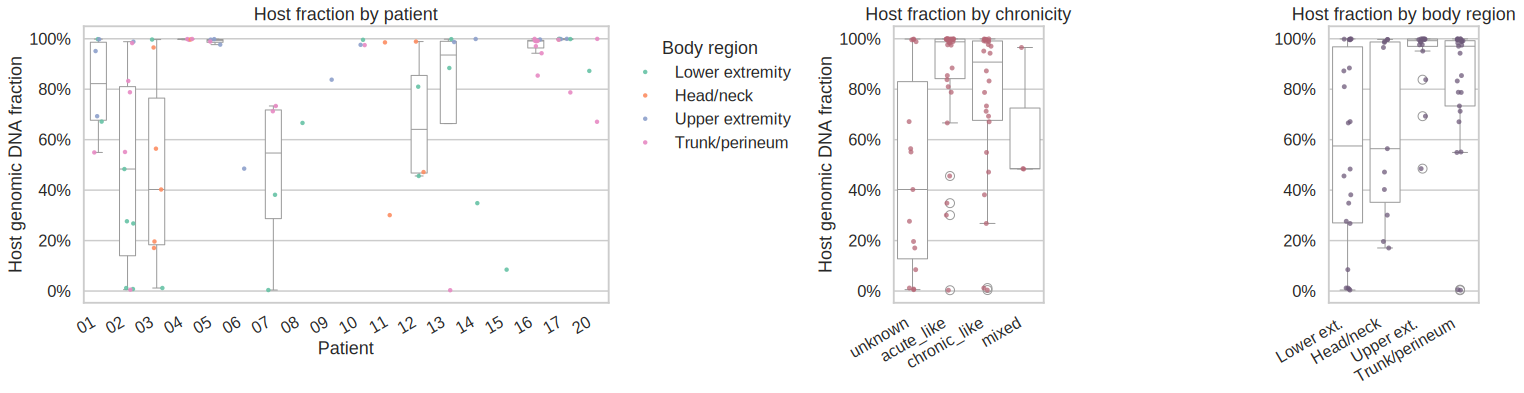

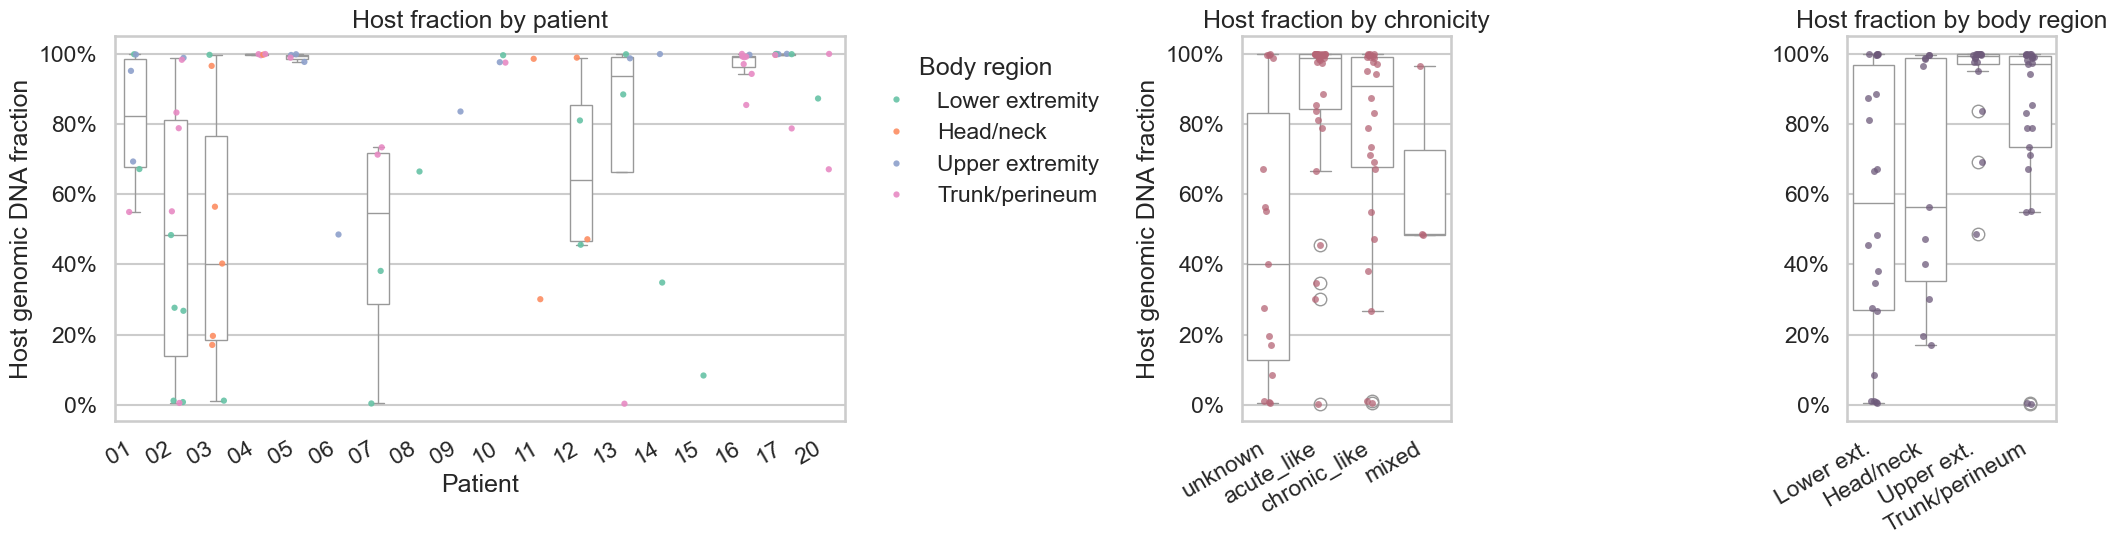

In [3]:
fig, axes = plt.subplots(
    1, 3, figsize=(21, 5.8), gridspec_kw={"width_ratios": [3.5, 1.0, 1.0]}
)

patient_order = (
    host_plot_df["patient_id"]
    .astype(str)
    .dropna()
    .drop_duplicates()
    .sort_values(key=lambda s: pd.to_numeric(s, errors="coerce").fillna(9999))
    .tolist()
)
body_region_order = [
    region
    for region in ["lower_extremity", "head_neck", "upper_extremity", "trunk_perineum"]
    if region in set(host_plot_df["body_region"].astype(str))
]
if not body_region_order:
    body_region_order = sorted(
        host_plot_df["body_region"].dropna().astype(str).unique().tolist()
    )
body_region_labels = {
    "lower_extremity": "Lower extremity",
    "head_neck": "Head/neck",
    "upper_extremity": "Upper extremity",
    "trunk_perineum": "Trunk/perineum",
}
body_palette = dict(
    zip(body_region_order, sns.color_palette("Set2", n_colors=len(body_region_order)))
)
patient_counts = host_plot_df["patient_id"].astype(str).value_counts()
box_patients = set(patient_counts[patient_counts > 3].index.tolist())
box_df = host_plot_df.loc[
    host_plot_df["patient_id"].astype(str).isin(box_patients)
].copy()

if not box_df.empty:
    sns.boxplot(
        data=box_df,
        x="patient_id",
        y="host_removed_fraction",
        order=patient_order,
        color="white",
        fliersize=0,
        width=0.55,
        linewidth=1.0,
        ax=axes[0],
    )
sns.stripplot(
    data=host_plot_df,
    x="patient_id",
    y="host_removed_fraction",
    hue="body_region",
    order=patient_order,
    hue_order=body_region_order,
    palette=body_palette,
    dodge=False,
    jitter=0.22,
    size=4.5,
    alpha=0.9,
    ax=axes[0],
)
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    display_labels = [body_region_labels.get(label, label) for label in labels]
    axes[0].legend(
        handles,
        display_labels,
        title="Body region",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=False,
    )
axes[0].set_title("Host fraction by patient")
axes[0].set_xlabel("Patient")
axes[0].set_ylabel("Host genomic DNA fraction")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

chronicity_order = ["unknown", "acute_like", "chronic_like", "mixed"]
sns.boxplot(
    data=host_plot_df,
    x="chronicity_group",
    y="host_removed_fraction",
    order=chronicity_order,
    color="white",
    ax=axes[1],
)
sns.stripplot(
    data=host_plot_df,
    x="chronicity_group",
    y="host_removed_fraction",
    order=chronicity_order,
    color="#b56576",
    size=5,
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("Host fraction by chronicity")
axes[1].set_xlabel("")
axes[1].set_ylabel("Host genomic DNA fraction")
axes[1].tick_params(axis="x", rotation=25)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))

body_order = ["lower_extremity", "head_neck", "upper_extremity", "trunk_perineum"]
sns.boxplot(
    data=host_plot_df,
    x="body_region",
    y="host_removed_fraction",
    order=body_order,
    color="white",
    ax=axes[2],
)
sns.stripplot(
    data=host_plot_df,
    x="body_region",
    y="host_removed_fraction",
    order=body_order,
    color="#6d597a",
    size=5,
    alpha=0.75,
    ax=axes[2],
)
axes[2].set_title("Host fraction by body region")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].set_xticklabels(
    ["Lower ext.", "Head/neck", "Upper ext.", "Trunk/perineum"], rotation=25
)
axes[2].yaxis.set_major_formatter(PercentFormatter(1))

for ax in axes:
    # Rotate x axis tick labels by 30 degrees and align to the right
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


fig.tight_layout()
fig_14_01_path = wc.figure_path(context, 18, "host_fraction_overview")
fig.savefig(fig_14_01_path, bbox_inches="tight")
fig.savefig(fig_14_01_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)
display(SVG(filename=str(wc.figure_path(context, 18, "host_fraction_overview"))))

## Figure 19. Gaussian Mixed-Model Summary


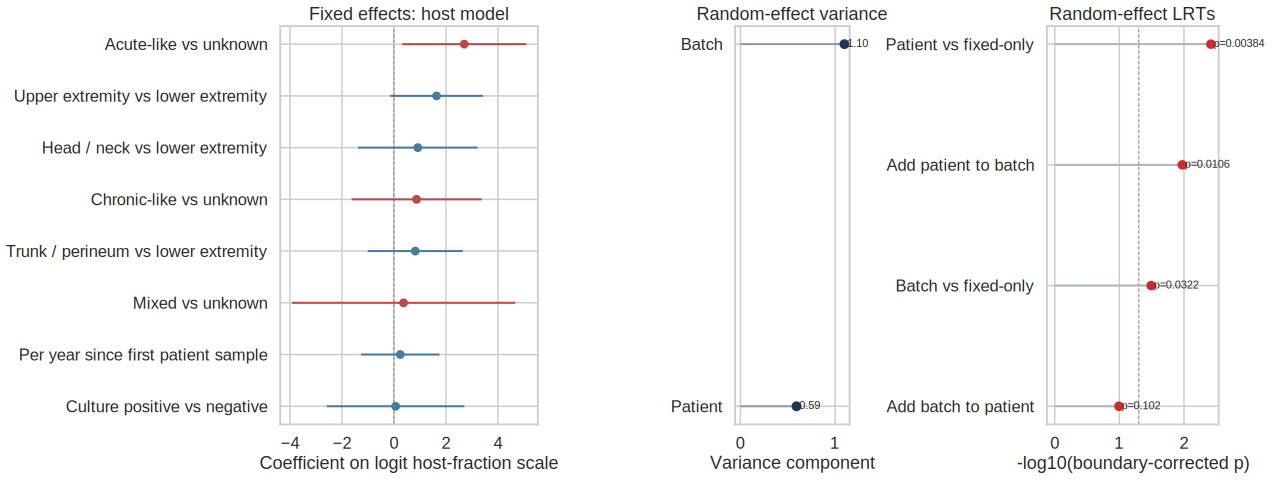

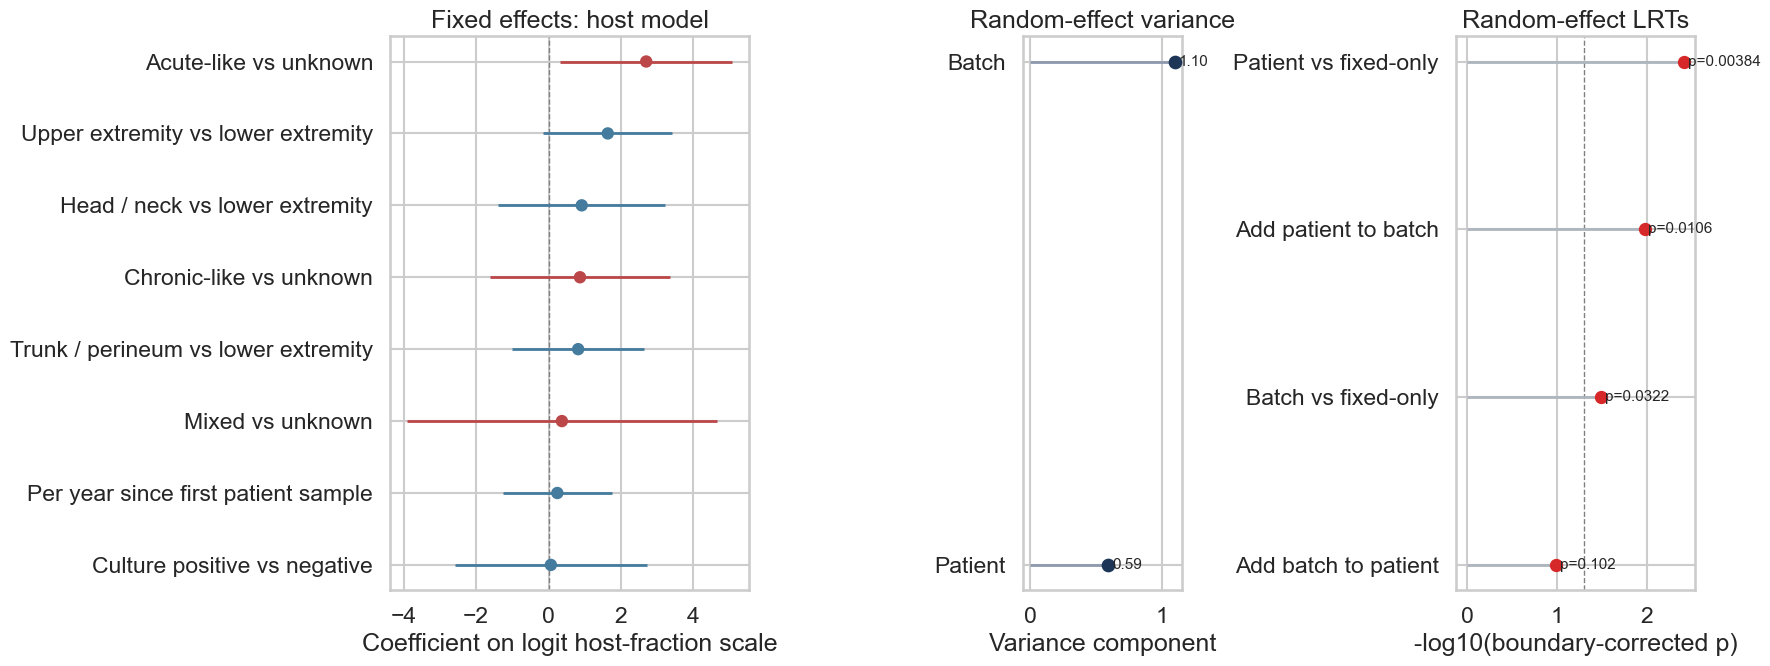

In [4]:
fig = plt.figure(figsize=(18, 7))
grid = fig.add_gridspec(1, 3, width_ratios=[1.8, 0.8, 1.2])
ax_forest = fig.add_subplot(grid[0, 0])
ax_var = fig.add_subplot(grid[0, 1])
ax_lrt = fig.add_subplot(grid[0, 2])

plot_df = host_model_effects.copy().sort_values("estimate")
y = np.arange(plot_df.shape[0])
colors = np.where(plot_df["factor_family"] == "chronicity_group", "#bc4749", "#457b9d")
ax_forest.axvline(0, color="grey", linestyle="--", linewidth=1)
ax_forest.hlines(
    y, plot_df["conf_low"], plot_df["conf_high"], color=colors, linewidth=2
)
ax_forest.scatter(plot_df["estimate"], y, color=colors, s=55, zorder=3)
ax_forest.set_yticks(y)
ax_forest.set_yticklabels(plot_df["term_label"])
ax_forest.set_xlabel("Coefficient on logit host-fraction scale")
ax_forest.set_title("Fixed effects: host model")

host_model_status = host_status.loc[
    (host_status["record_type"] == "model_fit")
    & (host_status["model_name"] == advanced.HOST_MODEL_NAME)
].iloc[0]
var_df = pd.DataFrame(
    {
        "component": ["Patient", "Batch"],
        "variance": [host_model_status["patient_var"], host_model_status["batch_var"]],
    }
)
ax_var.hlines(var_df["component"], 0, var_df["variance"], color="#8d99ae", linewidth=2)
ax_var.scatter(var_df["variance"], var_df["component"], color="#1d3557", s=70, zorder=3)
for _, row in var_df.iterrows():
    ax_var.text(
        row["variance"] + 0.03,
        row["component"],
        f"{row['variance']:.2f}",
        va="center",
        fontsize=11,
    )
ax_var.set_title("Random-effect variance")
ax_var.set_xlabel("Variance component")

lrt_df = host_status.loc[
    (host_status["record_type"] == "random_effect_test")
    & (host_status["model_name"] == advanced.HOST_MODEL_NAME)
].copy()
label_map = {
    "patient_only_vs_fixed": "Patient vs fixed-only",
    "batch_only_vs_fixed": "Batch vs fixed-only",
    "batch_added_to_patient": "Add batch to patient",
    "patient_added_to_batch": "Add patient to batch",
}
lrt_df["test_label"] = lrt_df["tested_effect"].map(label_map)
lrt_df["neglog10_p"] = -np.log10(lrt_df["pvalue_boundary"].clip(lower=1e-12))
lrt_df = lrt_df.sort_values("neglog10_p")
ax_lrt.axvline(-np.log10(0.05), color="grey", linestyle="--", linewidth=1)
ax_lrt.hlines(
    lrt_df["test_label"], 0, lrt_df["neglog10_p"], color="#adb5bd", linewidth=2
)
ax_lrt.scatter(
    lrt_df["neglog10_p"], lrt_df["test_label"], color="#d62828", s=65, zorder=3
)
for _, row in lrt_df.iterrows():
    ax_lrt.text(
        row["neglog10_p"] + 0.04,
        row["test_label"],
        f"p={row['pvalue_boundary']:.3g}",
        va="center",
        fontsize=11,
    )
ax_lrt.set_title("Random-effect LRTs")
ax_lrt.set_xlabel("-log10(boundary-corrected p)")

fig.tight_layout()
fig_14_02_path = wc.figure_path(context, 19, "host_gaussian_mixed_summary")
fig.savefig(fig_14_02_path, bbox_inches="tight")
fig.savefig(fig_14_02_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)
display(SVG(filename=str(wc.figure_path(context, 19, "host_gaussian_mixed_summary"))))

## Figure 20. Focused Chronicity And Location Follow-Up


/tmp/ipykernel_2755151/3914045286.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2755151/3914045286.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


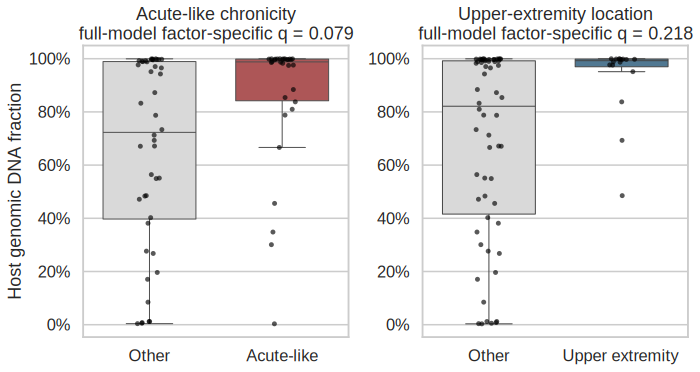

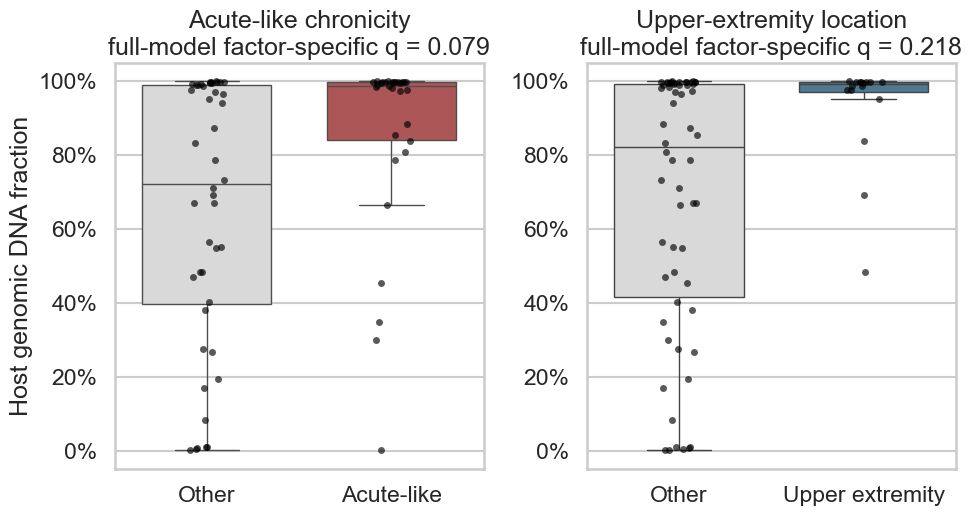

In [5]:
acute_q = float(
    host_model_effects.loc[
        host_model_effects["term"]
        == "C(chronicity_group, Treatment('unknown'))[T.acute_like]",
        "posthoc_qvalue",
    ].iloc[0]
)
upper_q = float(
    host_model_effects.loc[
        host_model_effects["term"]
        == "C(body_region, Treatment('lower_extremity'))[T.upper_extremity]",
        "posthoc_qvalue",
    ].iloc[0]
)


box_width = 0.7
fliersize = 0
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))

sns.boxplot(
    data=host_plot_df,
    x="acute_like_binary",
    y="host_removed_fraction",
    order=["Other", "Acute-like"],
    palette=["#d9d9d9", "#bc4749"],
    width=box_width,
    fliersize=fliersize,
    ax=axes[0],
)
sns.stripplot(
    data=host_plot_df,
    x="acute_like_binary",
    y="host_removed_fraction",
    order=["Other", "Acute-like"],
    color="black",
    alpha=0.65,
    size=5,
    ax=axes[0],
)
axes[0].set_title(
    f"Acute-like chronicity\nfull-model factor-specific q = {acute_q:.3f}"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Host genomic DNA fraction")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

sns.boxplot(
    data=host_plot_df,
    x="upper_extremity_binary",
    y="host_removed_fraction",
    order=["Other", "Upper extremity"],
    palette=["#d9d9d9", "#457b9d"],
    width=box_width,
    fliersize=fliersize,
    ax=axes[1],
)
sns.stripplot(
    data=host_plot_df,
    x="upper_extremity_binary",
    y="host_removed_fraction",
    order=["Other", "Upper extremity"],
    color="black",
    alpha=0.65,
    size=5,
    ax=axes[1],
)
axes[1].set_title(
    f"Upper-extremity location\nfull-model factor-specific q = {upper_q:.3f}"
)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))

fig.tight_layout()
fig_14_03_path = wc.figure_path(context, 20, "host_gaussian_followup")
fig.savefig(fig_14_03_path, bbox_inches="tight")
fig.savefig(fig_14_03_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)
display(SVG(filename=str(wc.figure_path(context, 20, "host_gaussian_followup"))))

## Figure 21. Patient And Batch Random Intercepts


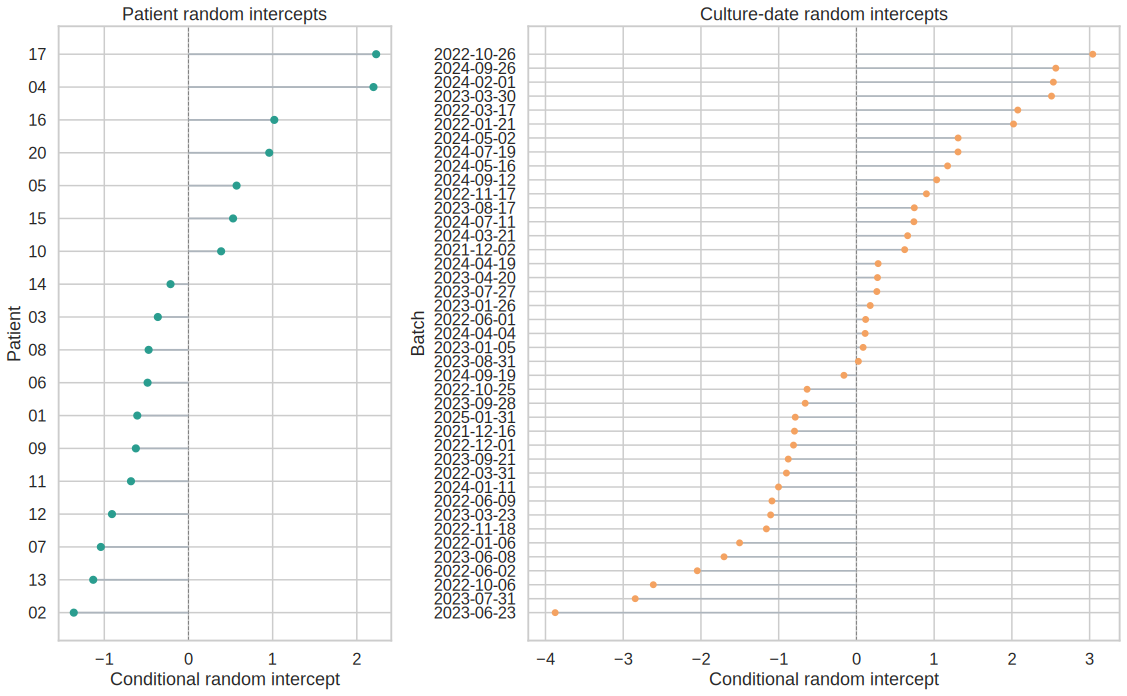

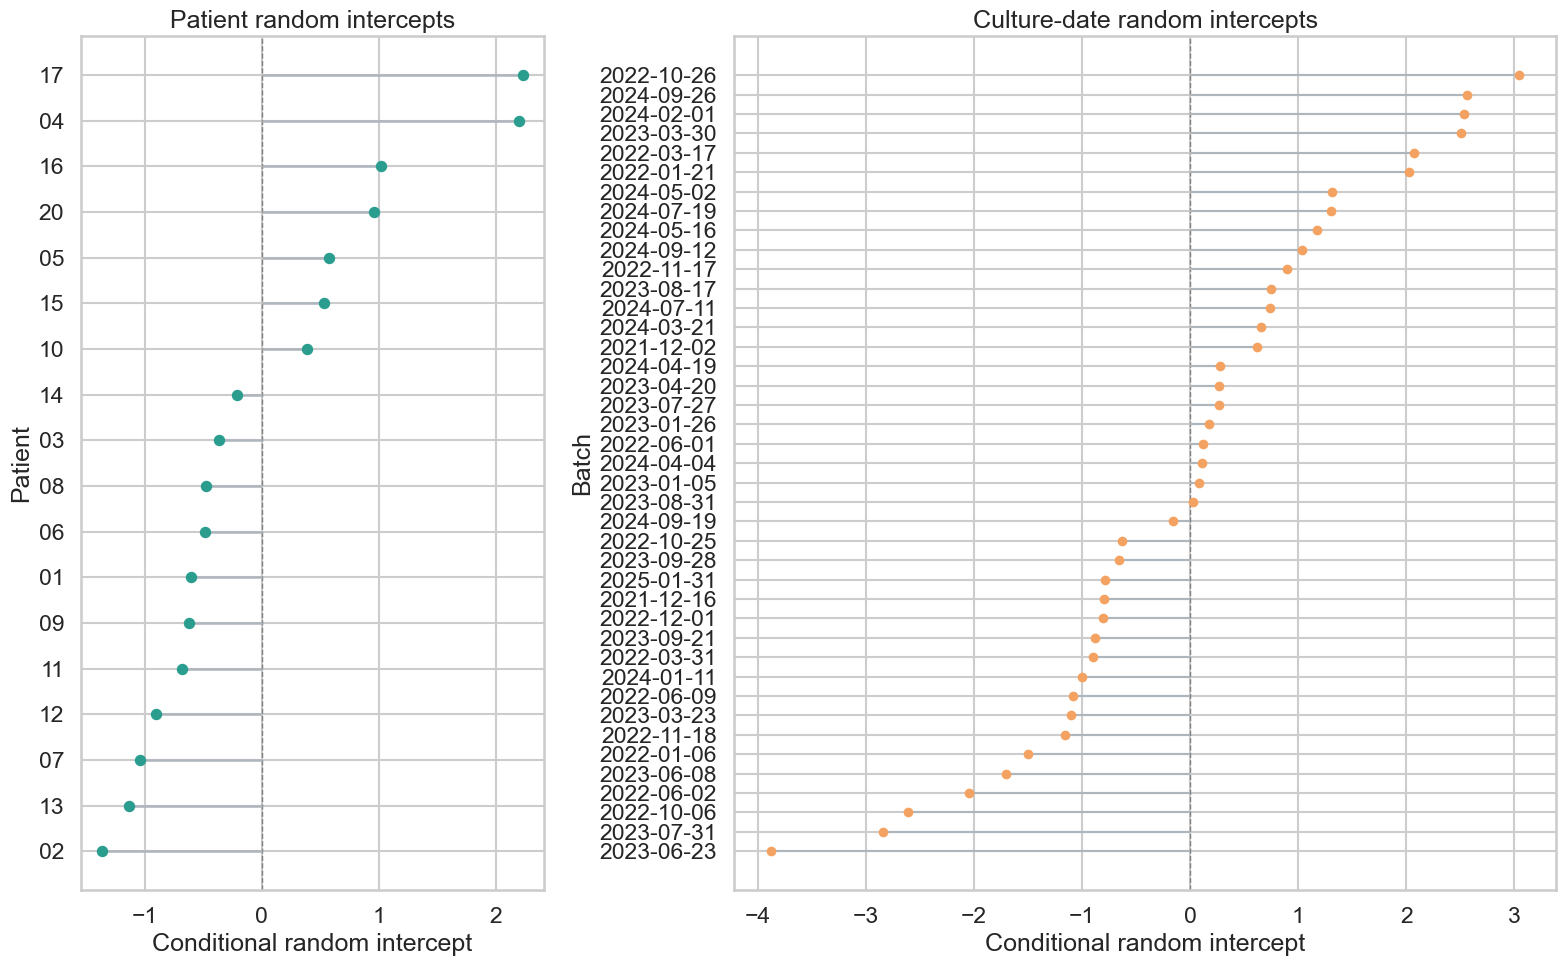

In [6]:
patient_df = random_effects_df.loc[random_effects_df["group"] == "patient"].sort_values(
    "random_intercept"
)
batch_df = random_effects_df.loc[random_effects_df["group"] == "batch"].sort_values(
    "random_intercept"
)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 10), gridspec_kw={"width_ratios": [0.9, 1.6]}
)

axes[0].axvline(0, color="grey", linestyle="--", linewidth=1)
axes[0].hlines(
    patient_df["level"],
    0,
    patient_df["random_intercept"],
    color="#adb5bd",
    linewidth=1.8,
)
axes[0].scatter(
    patient_df["random_intercept"], patient_df["level"], color="#2a9d8f", s=45, zorder=3
)
axes[0].set_title("Patient random intercepts")
axes[0].set_xlabel("Conditional random intercept")
axes[0].set_ylabel("Patient")

axes[1].axvline(0, color="grey", linestyle="--", linewidth=1)
axes[1].hlines(
    batch_df["level"], 0, batch_df["random_intercept"], color="#adb5bd", linewidth=1.5
)
axes[1].scatter(
    batch_df["random_intercept"], batch_df["level"], color="#f4a261", s=30, zorder=3
)
axes[1].set_title("Culture-date random intercepts")
axes[1].set_xlabel("Conditional random intercept")
axes[1].set_ylabel("Batch")

fig.tight_layout()
fig_14_04_path = wc.figure_path(context, 21, "host_gaussian_random_intercepts")
fig.savefig(fig_14_04_path, bbox_inches="tight")
fig.savefig(fig_14_04_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)
display(
    SVG(filename=str(wc.figure_path(context, 21, "host_gaussian_random_intercepts")))
)

## Review The Numbered Outputs


In [7]:
display(
    pd.read_csv(
        wc.table_path(context, 37, "host_gaussian_random_effects"), sep="\t"
    ).head(20)
)

,group,level,random_intercept
0,batch,2023-06-23,-3.875473
1,batch,2023-07-31,-2.845696
2,batch,2022-10-06,-2.612907
3,batch,2022-06-02,-2.047259
4,batch,2023-06-08,-1.702999
5,batch,2022-01-06,-1.503102
6,batch,2022-11-18,-1.158243
7,batch,2023-03-23,-1.103428
8,batch,2022-06-09,-1.086439
9,batch,2024-01-11,-1.002370
